### Import Libraries

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from scipy.stats import median_abs_deviation
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold

### Load the Datasets

In [20]:
#combined_df = pd.read_csv('combined_Octoparse_categorized.csv')
combined_df = pd.read_csv('../../Cleaned Data/combined_df.csv')
target_variable = 'Number of Reviewers'
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Data columns (total 45 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1863 non-null   object 
 1   Name                                      1863 non-null   object 
 2   Latitude                                  1863 non-null   float64
 3   Longitude                                 1863 non-null   float64
 4   Category                                  1863 non-null   object 
 5   Rating                                    1863 non-null   object 
 6   Popularity                                1863 non-null   float64
 7   Google Place ID                           1863 non-null   object 
 8   Business Status                           1863 non-null   object 
 9   Distance (m)                              1863 non-null   float64
 10  Cluster                             

## Data Pre-processing

In [21]:
pd.set_option('display.max_columns', None)
#combined_df[combined_df['Indirect Competition - Food & Dining/POI Density'].isnull()]

### Drop Irrelevent columns

In [22]:
# Drop irrelevant columns
"""
drop_columns = ['Address', 'Country', 'State', 'City', 'Category', 'Price_Range', 
                'Current_Status', 'Title', 'Rating', 'Google_id',
                'Latitude', 'Longitude', 'Religious Institutions', 'Health', 
                'Public & Government Services', 'Entertainment & Recreation', 'Transportation & Travel',
                'Finance & Services', 'Retail & Shopping', 'Home & Construction Services', 'Beauty & Wellness',
                'Hotels & Hospitality', 'Education'
               ]
"""
# Drop irrelevant columns
drop_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs'
               , 'Google Rating', 'Business Name']

combined_df.drop(columns=drop_columns, inplace=True, errors='ignore')


In [23]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Popularity                               1863 non-null   float64
 1   generalCategory                          1863 non-null   int64  
 2   Religious Institutions                   1863 non-null   int64  
 3   Coffee Shops                             1863 non-null   int64  
 4   Food & Dining                            1863 non-null   int64  
 5   Restaurants                              1863 non-null   int64  
 6   Home & Construction Services             1863 non-null   int64  
 7   Entertainment & Recreation               1863 non-null   int64  
 8   Retail & Shopping                        1863 non-null   int64  
 9   Finance & Services                       1863 non-null   int64  
 10  Education                                1863 no

### Drop Rows with missing #of Reviewrs

In [24]:
# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
combined_df[target_variable] = pd.to_numeric(combined_df[target_variable], errors='coerce')

# Drop rows where 'Number of Reviewers' is NaN (if you want to ignore them in analysis)
combined_df = combined_df.dropna(subset=[target_variable])

In [25]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1861 entries, 0 to 1862
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Popularity                               1861 non-null   float64
 1   generalCategory                          1861 non-null   int64  
 2   Religious Institutions                   1861 non-null   int64  
 3   Coffee Shops                             1861 non-null   int64  
 4   Food & Dining                            1861 non-null   int64  
 5   Restaurants                              1861 non-null   int64  
 6   Home & Construction Services             1861 non-null   int64  
 7   Entertainment & Recreation               1861 non-null   int64  
 8   Retail & Shopping                        1861 non-null   int64  
 9   Finance & Services                       1861 non-null   int64  
 10  Education                                1861 non-nul

### Find Null values

In [26]:
print(combined_df.isnull().sum())

Popularity                                  0
generalCategory                             0
Religious Institutions                      0
Coffee Shops                                0
Food & Dining                               0
Restaurants                                 0
Home & Construction Services                0
Entertainment & Recreation                  0
Retail & Shopping                           0
Finance & Services                          0
Education                                   0
Health                                      0
Public & Government Services                0
Hotels & Hospitality                        0
Transportation & Travel                     0
Beauty & Wellness                           0
POI Density                                 0
Avg Rating - Food & Dining                 15
Competition - Food & Dining/POI Density     0
Population Within 1km                       0
Number of Reviewers                         0
Avg_NumOfReviewers - Food & Dining

### Fill Missing Values with median

In [28]:
#Fill missing values using median of the specfic food-chain

combined_df["Avg Rating - Food & Dining"] = combined_df["Avg Rating - Food & Dining"].fillna(combined_df["Avg Rating - Food & Dining"].median())
combined_df["Avg_NumOfReviewers - Food & Dining"] = combined_df["Avg_NumOfReviewers - Food & Dining"].fillna(combined_df["Avg_NumOfReviewers - Food & Dining"].median())
combined_df["Avg_NumOfReviewers_SameCategory"] = combined_df["Avg_NumOfReviewers_SameCategory"].fillna(combined_df["Avg_NumOfReviewers_SameCategory"].median())
combined_df["Total Num of Reviewers - Food & Dining"] = combined_df["Total Num of Reviewers - Food & Dining"].fillna(combined_df["Total Num of Reviewers - Food & Dining"].median())
combined_df["Number of Reviewers"] = combined_df["Number of Reviewers"].fillna(
    combined_df.groupby("generalCategory")["Number of Reviewers"].transform("median")
)

print(combined_df.isnull().sum())

Popularity                                 0
generalCategory                            0
Religious Institutions                     0
Coffee Shops                               0
Food & Dining                              0
Restaurants                                0
Home & Construction Services               0
Entertainment & Recreation                 0
Retail & Shopping                          0
Finance & Services                         0
Education                                  0
Health                                     0
Public & Government Services               0
Hotels & Hospitality                       0
Transportation & Travel                    0
Beauty & Wellness                          0
POI Density                                0
Avg Rating - Food & Dining                 0
Competition - Food & Dining/POI Density    0
Population Within 1km                      0
Number of Reviewers                        0
Avg_NumOfReviewers - Food & Dining         0
Avg_NumOfR

In [29]:
#combined_df['general_category'] = (combined_df['keyword'] != 'Coffee shop').astype(int)
combined_df

,Popularity,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Food & Dining,Competition - Food & Dining/POI Density,Population Within 1km,Number of Reviewers,Avg_NumOfReviewers - Food & Dining,Avg_NumOfReviewers_SameCategory,Population Within 2km,Population Within 3km,Total Num of Reviewers - Food & Dining,Total Num of Reviewers - All POIs
0,0.968299,0,1,2,2,1,0,0,5,0,0,0,0,0,14,1,58,4.200000,0.034483,2120,153.0,194.0,194.0,19724,61651,389.0,4050
1,0.991283,0,1,2,9,8,0,3,4,2,0,0,0,0,3,1,56,4.100000,0.160714,10498,878.0,2357.0,453.0,53909,128780,21393.0,26379
2,0.963778,0,3,1,4,3,0,0,3,2,2,0,1,0,3,1,57,4.200000,0.070175,12828,29.0,2816.0,29.0,67458,158784,11293.0,14465
3,0.943726,0,1,1,14,13,0,0,18,4,0,2,0,3,1,6,58,3.992857,0.241379,56606,246.0,854.0,19.0,148696,253458,11966.0,17299
4,0.544394,0,2,3,16,13,0,0,8,6,0,2,0,7,2,5,58,3.975000,0.275862,72642,128.0,1379.0,492.0,155251,269213,22168.0,26715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1858,0.997484,1,1,4,16,11,0,2,39,0,1,2,0,0,0,0,58,3.956250,0.275862,18538,1026.0,592.0,554.0,75800,156481,9483.0,24057
1859,0.965308,1,0,3,14,10,0,0,21,5,1,3,1,3,0,2,58,4.000000,0.241379,30218,422.0,434.0,462.0,74468,129266,6088.0,10596
1860,0.725694,1,0,3,16,13,0,1,4,4,2,1,2,1,2,4,58,3.471429,0.275862,1702,264.0,97.0,90.0,20840,56903,1615.0,6193
1861,0.884345,1,2,2,8,6,0,3,9,3,1,3,1,2,4,1,59,4.242857,0.135593,11467,852.0,956.0,988.0,36621,91598,11403.0,39944


### Helper Functions (Highly Correlated Features, Outliers)

In [225]:
# Helper Functions to remove outliers and highly correlated features

def remove_outliers(X, y):
    """Remove outliers using IQR."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

    
# Remove Highly Correlated Features (Modified)
removed_corr_features = []  # List to store removed features

def remove_highly_correlated_features(X, threshold=0.9):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

### Visualization of Data Distribution

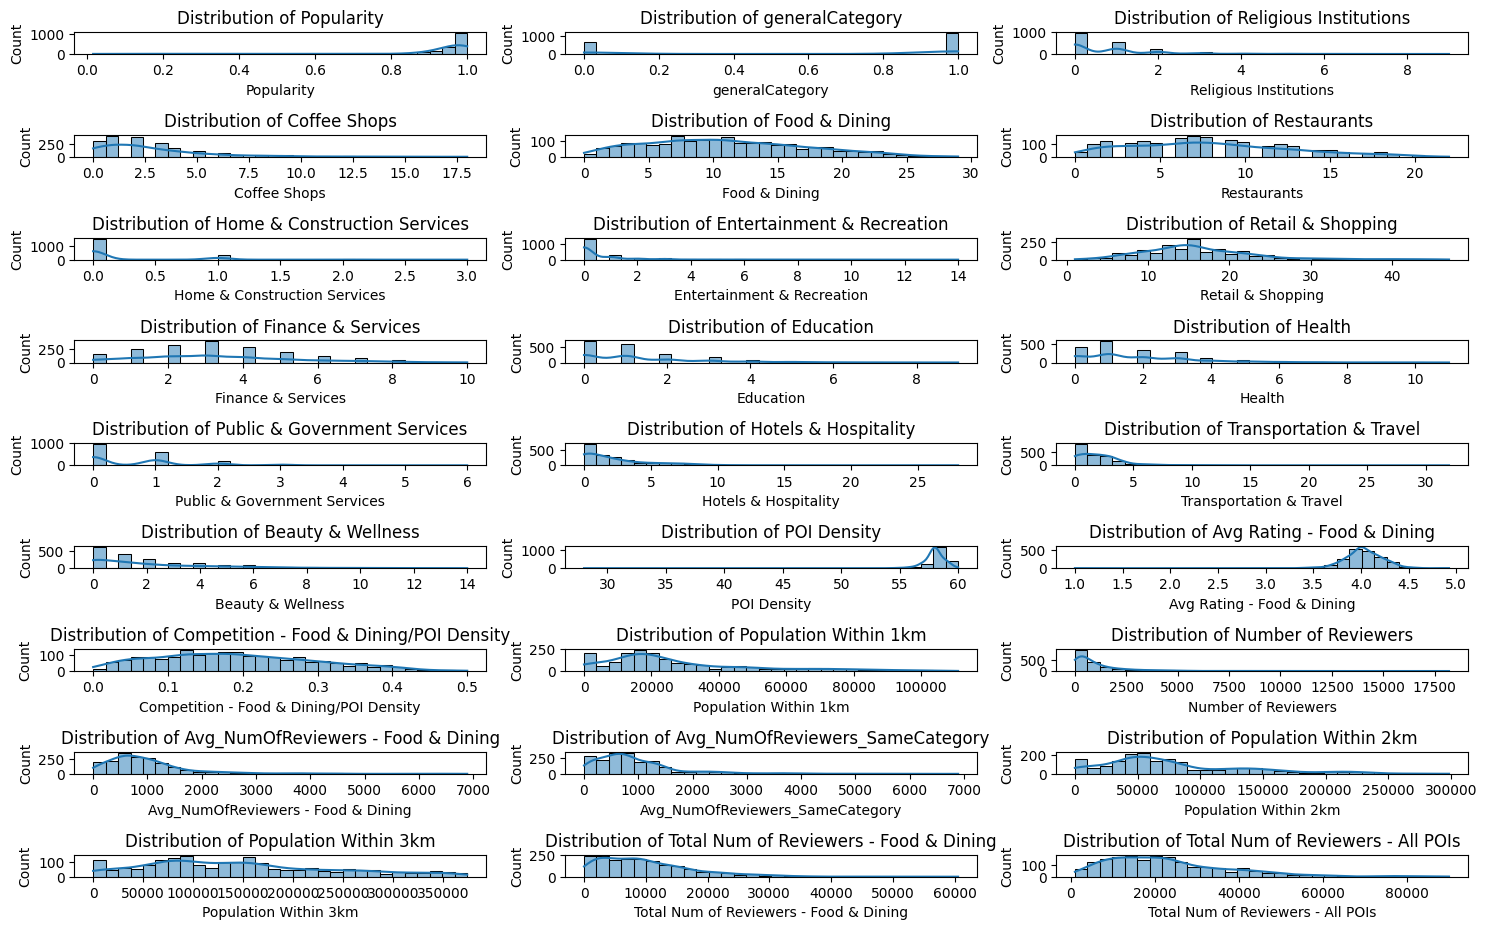

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot the distribution of all features in a DataFrame
def plot_feature_distributions(df):
    num_cols = df.select_dtypes(include=['number']).columns  # Select only numeric columns
    
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot((len(num_cols) // 3) + 1, 3, i)  # Create subplots with 3 columns
        sns.histplot(df[col], kde=True, bins=30)  # Histogram with KDE
        plt.title(f'Distribution of {col}')
    
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_feature_distributions(combined_df)


### Outliers Detection

In [31]:
# Select only numeric columns, excluding "Number of Reviews"
numeric_features = combined_df.select_dtypes(include=[np.number]).columns
#features = [col for col in numeric_features if col != "Review_Count"]

features = [col for col in numeric_features if col != target_variable]

# Function to detect outliers using IQR and count records with any outlier
def detect_outliers_iqr(df, features):
    outlier_counts = {}
    outlier_mask = np.zeros(df.shape[0], dtype=bool)  # Boolean mask to track rows with outliers

    for feature in features:
        Q1 = df[feature].quantile(0.25)  # First quartile
        Q3 = df[feature].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Create a mask for outliers in this feature
        feature_outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
        outlier_counts[feature] = feature_outliers.sum()  # Count outliers per feature
        outlier_mask |= feature_outliers  # Combine with the overall mask

    # Count records that contain at least one outlier
    num_records_with_outliers = np.sum(outlier_mask)
    
    return outlier_counts, num_records_with_outliers

# Detect outliers
outlier_results, num_outlier_records = detect_outliers_iqr(combined_df, features)

# Print the number of outliers for each feature
print("Outlier Counts Per Feature:")
for feature, count in outlier_results.items():
    print(f"{feature}: {count} outliers")

# Print the number of records that contain at least one outlier
print(f"\nNumber of records containing at least one outlier: {num_outlier_records}")


Outlier Counts Per Feature:
Popularity: 186 outliers
generalCategory: 0 outliers
Religious Institutions: 160 outliers
Coffee Shops: 80 outliers
Food & Dining: 1 outliers
Restaurants: 1 outliers
Home & Construction Services: 345 outliers
Entertainment & Recreation: 143 outliers
Retail & Shopping: 66 outliers
Finance & Services: 70 outliers
Education: 41 outliers
Health: 36 outliers
Public & Government Services: 98 outliers
Hotels & Hospitality: 138 outliers
Transportation & Travel: 91 outliers
Beauty & Wellness: 75 outliers
POI Density: 717 outliers
Avg Rating - Food & Dining: 44 outliers
Competition - Food & Dining/POI Density: 1 outliers
Population Within 1km: 148 outliers
Avg_NumOfReviewers - Food & Dining: 116 outliers
Avg_NumOfReviewers_SameCategory: 108 outliers
Population Within 2km: 69 outliers
Population Within 3km: 0 outliers
Total Num of Reviewers - Food & Dining: 46 outliers
Total Num of Reviewers - All POIs: 51 outliers

Number of records containing at least one outlier: 15

### Data Transformation

<class 'pandas.core.frame.DataFrame'>
Index: 1861 entries, 0 to 1862
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Popularity                               1861 non-null   float64
 1   generalCategory                          1861 non-null   int64  
 2   Religious Institutions                   1861 non-null   int64  
 3   Coffee Shops                             1861 non-null   int64  
 4   Food & Dining                            1861 non-null   int64  
 5   Restaurants                              1861 non-null   int64  
 6   Home & Construction Services             1861 non-null   int64  
 7   Entertainment & Recreation               1861 non-null   int64  
 8   Retail & Shopping                        1861 non-null   int64  
 9   Finance & Services                       1861 non-null   int64  
 10  Education                                1861 non-nul

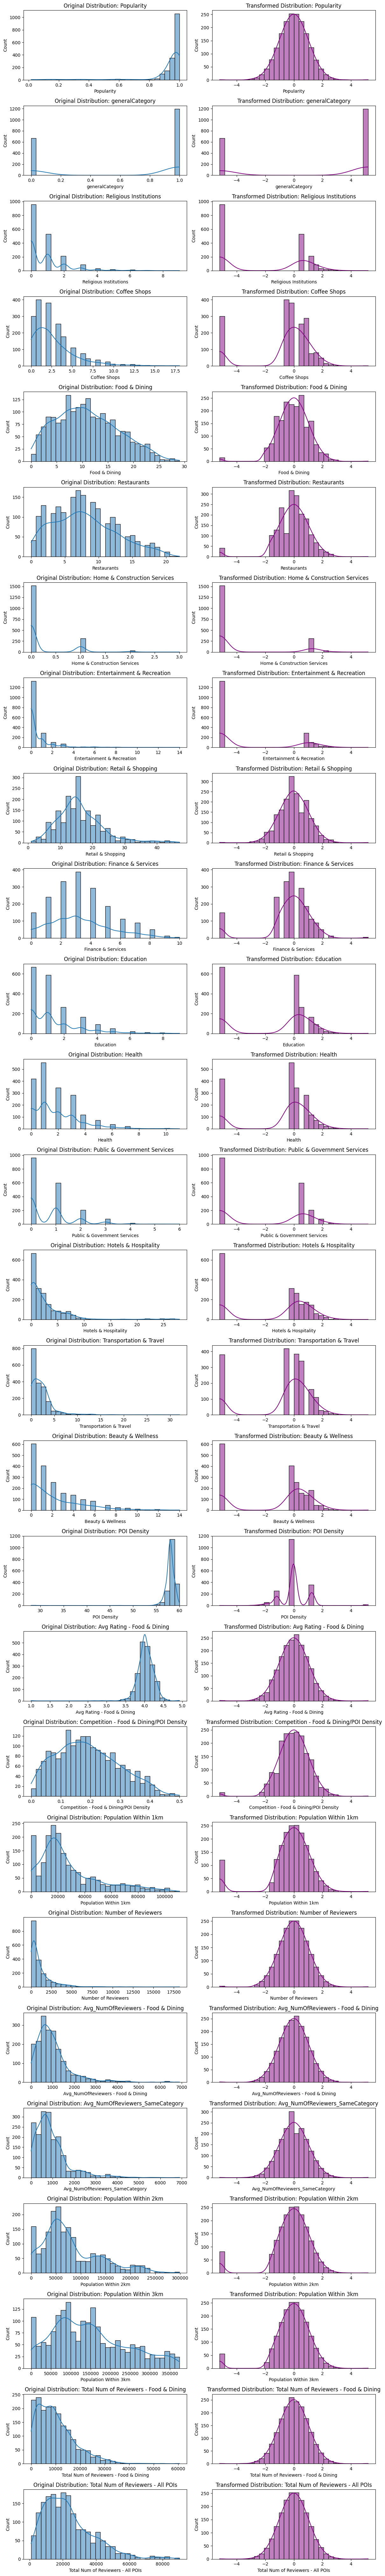

,Popularity,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Food & Dining,Competition - Food & Dining/POI Density,Population Within 1km,Number of Reviewers,Avg_NumOfReviewers - Food & Dining,Avg_NumOfReviewers_SameCategory,Population Within 2km,Population Within 3km,Total Num of Reviewers - Food & Dining,Total Num of Reviewers - All POIs
0,-0.150410,-5.199338,0.407442,-0.052716,-1.588771,-1.649237,-5.199338,-5.199338,-1.985876,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,2.511791,-0.170185,-0.022584,0.892038,-1.584354,-1.338052,-0.893908,-1.319216,-1.177055,-1.175260,-0.931637,-1.911329,-1.781344
1,0.682493,-5.199338,0.407442,-0.052716,-0.217488,0.111890,-5.199338,1.579968,-2.196894,-0.526417,-5.199338,-5.199338,-5.199338,-5.199338,0.604448,-0.170185,-1.851734,0.393847,-0.152391,-0.901351,0.315063,1.519250,-0.653488,-0.218750,-0.083696,1.308307,0.456997
2,-0.268317,-5.199338,1.537691,-0.616541,-1.050924,-0.931971,-5.199338,-5.199338,-2.483413,-0.526417,0.658043,-5.199338,0.461215,-5.199338,0.604448,-0.170185,-1.197193,0.892038,-0.969427,-0.694417,-1.654145,1.785239,-2.116241,0.086555,0.263776,0.376314,-0.452035
3,-0.593888,-5.199338,0.407442,-0.616541,0.509202,1.018778,-5.199338,-5.199338,0.462610,0.455640,-5.199338,0.296607,-5.199338,0.556927,-0.476619,1.355761,-0.022584,-0.247134,0.513491,1.160722,-0.599937,0.074189,-2.575483,1.126517,0.974541,0.444802,-0.240572
4,-1.540539,-5.199338,1.068522,0.385726,0.790168,1.018778,-5.199338,-5.199338,-1.310017,1.197193,-5.199338,0.296607,-5.199338,1.301191,0.081638,1.097845,-0.022584,-0.369558,0.783330,1.490335,-0.975466,0.832643,-0.558392,1.218002,1.102440,1.381715,0.481923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1858,1.335616,5.199338,0.407442,0.724973,0.790168,0.667419,-5.199338,1.255743,2.119668,-5.199338,0.040157,0.296607,-5.199338,-5.199338,-5.199338,-5.199338,-0.022584,-0.483658,0.783330,-0.139457,0.452858,-0.424633,-0.408546,0.270485,0.234090,0.139951,0.288476
1859,-0.228387,5.199338,-5.199338,0.385726,0.509202,0.503497,-5.199338,-5.199338,0.855287,0.858910,0.040157,0.788455,0.461215,0.556927,-5.199338,0.279606,-0.022584,-0.165095,0.513491,0.492339,-0.234219,-0.812654,-0.636387,0.249805,-0.079120,-0.359879,-0.824750
1860,-1.358879,5.199338,-5.199338,0.385726,0.790168,1.018778,-5.199338,0.805692,-2.196894,0.455640,0.658043,-0.318969,1.242061,-0.143512,0.081638,0.842694,-0.022584,-2.325972,0.783330,-1.371657,-0.546700,-1.694923,-1.597698,-1.102440,-1.025123,-1.265034,-1.404516
1861,-1.138849,5.199338,1.068522,-0.052716,-0.366873,-0.324254,-5.199338,1.579968,-1.114032,-0.017565,0.040157,0.788455,0.461215,0.248427,1.086456,-0.170185,1.252988,1.102440,-0.429351,-0.812654,0.283522,0.216204,0.397918,-0.819656,-0.437620,0.386533,1.059425


In [32]:
# Data Transformation and Scaling with QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
# Q1 = transformed_df['Popularity'].quantile(0.25)
# Q3 = transformed_df['Popularity'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()

# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply QuantileTransformer (normalize distribution)
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)  
# output_distribution='normal' ensures normal-like distribution
transformed_df[num_cols] = quantile_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
#minmax_scaler = MinMaxScaler()
#transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()


transformed_df


In [48]:
#Data Transformation and Scaling
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
"""
# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
#Q1 = transformed_df['Popularity'].quantile(0.25)
#Q3 = transformed_df['Popularity'].quantile(0.75)
#IQR = Q3 - Q1
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
#transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()
# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
#print("\nShapiro-Wilk Normality Test Results:")
#print(normality_df)

# Optionally, save results to a CSV file
#normality_df.to_csv("normality_test_results.csv", index=True)

# Q-Q Plots for each transformed feature
#fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

#for i, col in enumerate(num_cols):
#    probplot(transformed_df[col], dist="norm", plot=axes[i])
#    axes[i].set_title(f"Q-Q Plot: {col}")

#plt.tight_layout()
#plt.show()
transformed_df
"""

'\n# Copy DataFrame\ntransformed_df = combined_df.copy()\n\n# Remove outliers in \'Popularity\' using IQR method\n#Q1 = transformed_df[\'Popularity\'].quantile(0.25)\n#Q3 = transformed_df[\'Popularity\'].quantile(0.75)\n#IQR = Q3 - Q1\n#lower_bound = Q1 - 1.5 * IQR\n#upper_bound = Q3 + 1.5 * IQR\n#transformed_df = transformed_df[(transformed_df[\'Popularity\'] >= lower_bound) & (transformed_df[\'Popularity\'] <= upper_bound)]\n\ntransformed_df.info()\n# Select numerical columns\nnum_cols = transformed_df.select_dtypes(include=[\'number\']).columns\n\n# Store original distributions before transformation\noriginal_distributions = transformed_df[num_cols].copy()\n\n# Apply PowerTransformer (normalize distribution)\npower_transformer = PowerTransformer()\ntransformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])\n\n# Apply MinMaxScaler (scale to 0-1)\nminmax_scaler = MinMaxScaler()\ntransformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])\

In [ ]:
# Select only numeric columns, excluding "Number of Reviews"
numeric_features = combined_df.select_dtypes(include=[np.number]).columns
#features = [col for col in numeric_features if col != "Review_Count"]

features = [col for col in numeric_features if col != target_variable]

# Function to detect outliers using IQR and count records with any outlier
def detect_outliers_iqr(df, features):
    outlier_counts = {}
    outlier_mask = np.zeros(df.shape[0], dtype=bool)  # Boolean mask to track rows with outliers

    for feature in features:
        Q1 = df[feature].quantile(0.25)  # First quartile
        Q3 = df[feature].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Create a mask for outliers in this feature
        feature_outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
        outlier_counts[feature] = feature_outliers.sum()  # Count outliers per feature
        outlier_mask |= feature_outliers  # Combine with the overall mask

    # Count records that contain at least one outlier
    num_records_with_outliers = np.sum(outlier_mask)
    
    return outlier_counts, num_records_with_outliers

# Detect outliers
outlier_results, num_outlier_records = detect_outliers_iqr(combined_df, features)

# Print the number of outliers for each feature
print("Outlier Counts Per Feature:")
for feature, count in outlier_results.items():
    print(f"{feature}: {count} outliers")

# Print the number of records that contain at least one outlier
print(f"\nNumber of records containing at least one outlier: {num_outlier_records}")

## Dataset Splitting

In [33]:
# Separate based on 'general_category'
"""
coffee_df = combined_df[combined_df['general_category'] == 0].reset_index(drop=True)
restaurant_df = combined_df[combined_df['general_category'] == 1].reset_index(drop=True)
"""

coffee_df = combined_df[combined_df['generalCategory'] == 0].reset_index(drop=True)
restaurant_df = combined_df[combined_df['generalCategory'] == 1].reset_index(drop=True)

# Optional: print shapes to confirm
print(f"Coffee Shops: {coffee_df.shape[0]} rows")
print(f"Restaurants: {restaurant_df.shape[0]} rows")

# --- Training and Testing ----

# Split combined_df into 80% train and 20% test
combined_df_train, combined_df_test = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,  # for reproducibility
    shuffle=True      # ensure data is shuffled before splitting
)

# Optional: Print shape summary
print(f"Train set size: {combined_df_train.shape[0]}")
print(f"Test set size: {combined_df_test.shape[0]}")

combined_df_test.head()

# Define test keywords - Using specific food-chain
#test_coffee_keyword = "Dunkin"
#test_restaurant_keyword = "McDonald's"

# Coffee: train/test split
#coffee_test = combined_df[combined_df['Place_id'].isin(filtered_coffee['Place_id'])].reset_index(drop=True)
#coffee_train = combined_df[~combined_df['Place_id'].isin(filtered_coffee['Place_id'])].reset_index(drop=True)


# Restaurant: train/test split
#restaurant_test = combined_df[combined_df['Place_id'].isin(filtered_restaurants['Place_id'])].reset_index(drop=True)
#restaurant_train = combined_df[~combined_df['Place_id'].isin(filtered_restaurants['Place_id'])].reset_index(drop=True)

# Print results
#print("Coffee - Train:", coffee_train.shape[0], "Test:", coffee_test.shape[0])
#print("Restaurant - Train:", restaurant_train.shape[0], "Test:", restaurant_test.shape[0])


Coffee Shops: 667 rows
Restaurants: 1194 rows
Train set size: 1488
Test set size: 373


,Popularity,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Food & Dining,Competition - Food & Dining/POI Density,Population Within 1km,Number of Reviewers,Avg_NumOfReviewers - Food & Dining,Avg_NumOfReviewers_SameCategory,Population Within 2km,Population Within 3km,Total Num of Reviewers - Food & Dining,Total Num of Reviewers - All POIs
233,0.986055,0,0,4,14,10,0,1,17,4,1,3,0,2,0,4,58,4.028571,0.241379,28095,1578.0,494.0,637.0,75420,127312,7032.0,14588
450,0.692856,0,0,3,9,5,0,0,31,1,0,1,0,0,2,0,58,3.800000,0.155172,13477,231.0,398.0,221.0,51461,128646,3916.0,6370
1094,0.984264,1,0,2,21,18,0,1,14,3,0,1,0,8,0,2,58,4.026316,0.362069,25016,900.0,1061.0,1193.0,75796,141474,20730.0,24721
1577,0.915741,1,3,1,14,13,0,0,13,2,2,2,3,2,1,1,60,4.242857,0.233333,0,785.0,564.0,593.0,0,0,8012.0,12215
411,0.959366,0,2,2,3,1,0,2,10,3,2,6,1,0,2,0,58,4.233333,0.051724,19178,92.0,724.0,960.0,117150,262468,2174.0,19423


## Features Analyses 

### Pearson correlation

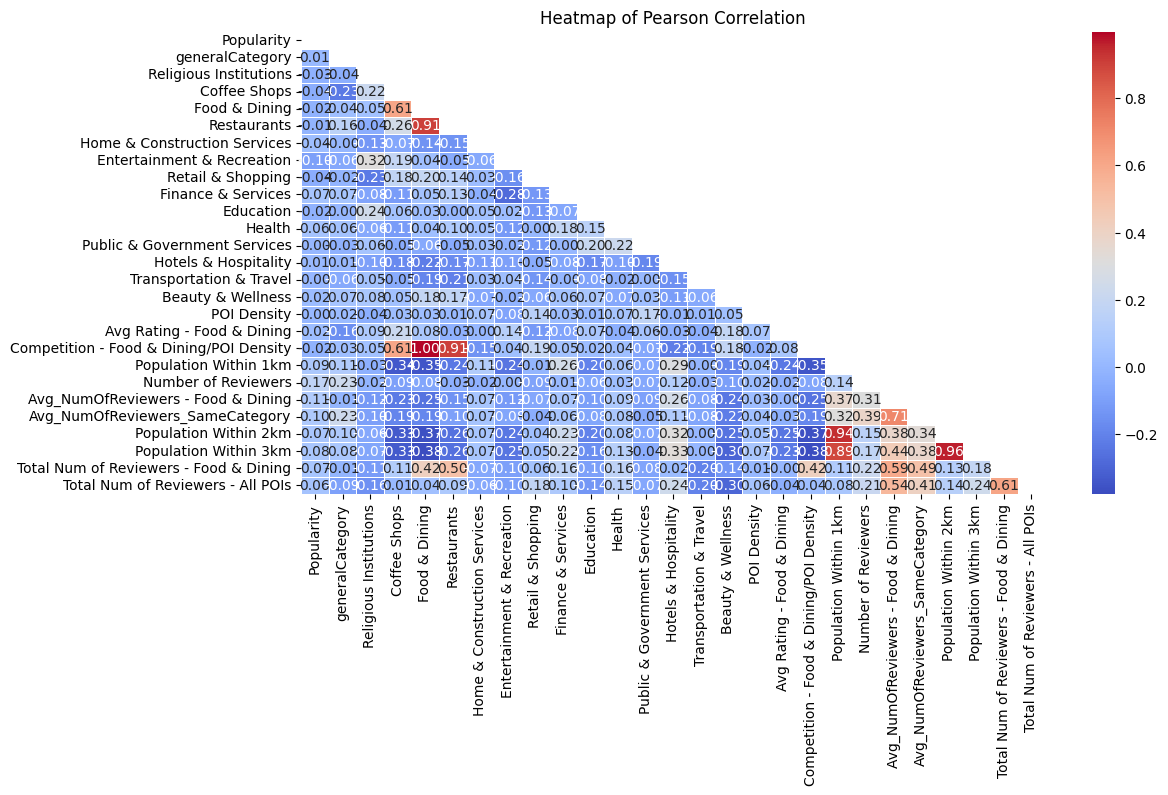

In [34]:
# Compute Pearson correlation

corr_matrix = combined_df.select_dtypes(include=['number']).corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()


### Scatterplots

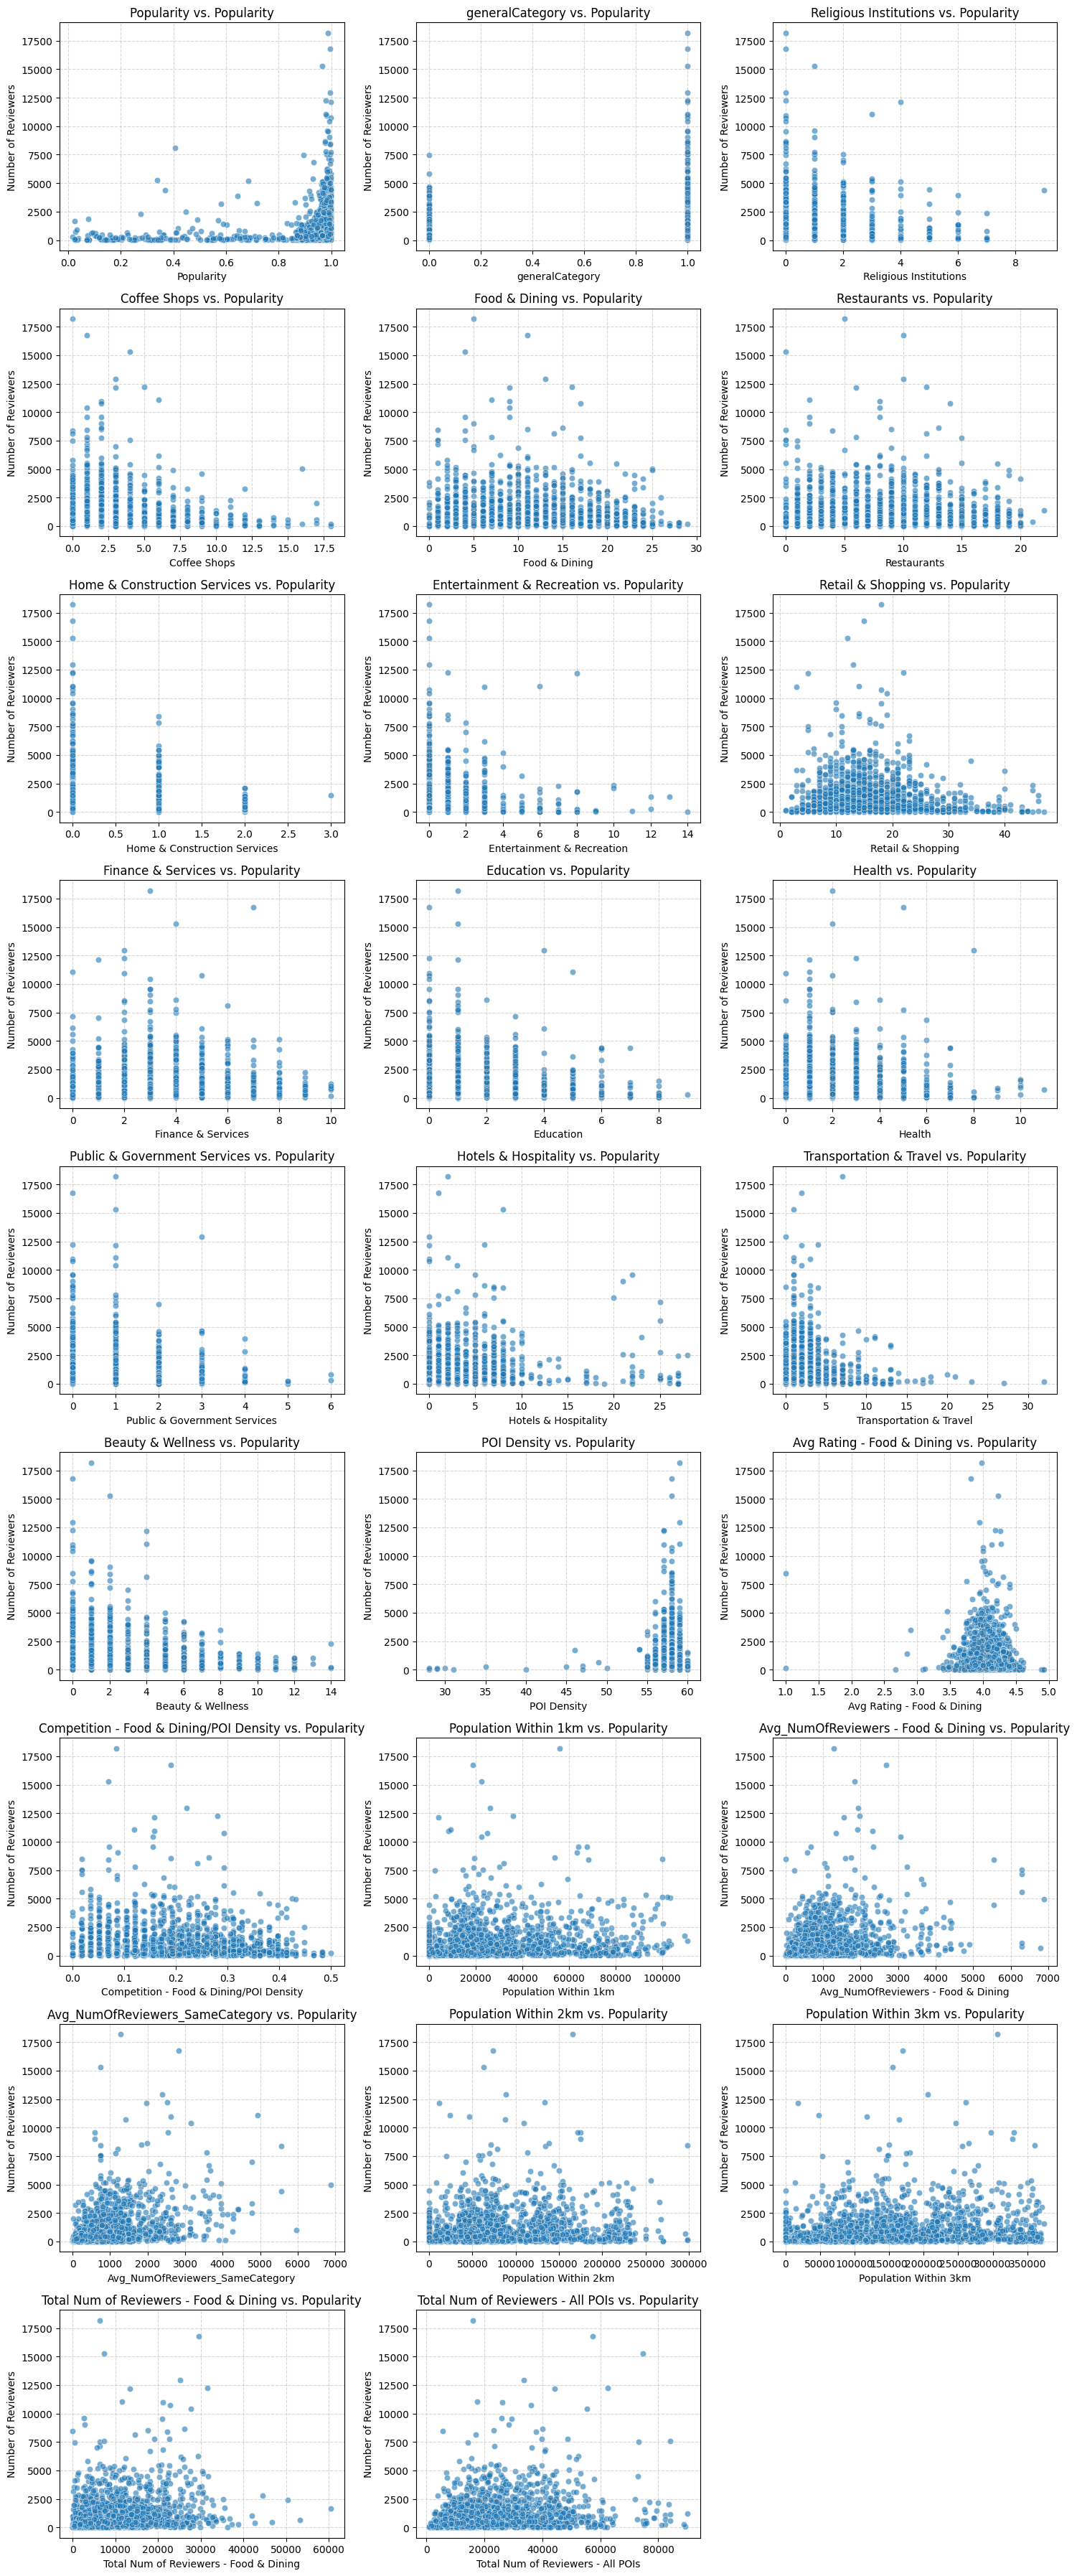

In [35]:
# Original Dataframe (WITHOUT transformation)
# Filter only numeric features (excluding target variable "Number of Reviewers")
numeric_features = combined_df.select_dtypes(include=np.number).columns
features_to_plot = [feature for feature in numeric_features if feature != target_variable]

# Define grid size
num_features = len(features_to_plot)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Compute required rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Loop through features and create scatter plots
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=combined_df[feature], y=combined_df[target_variable], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel(target_variable, fontsize=10)
    axes[i].set_title(f"{feature} vs. Popularity", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots if num_features < num_cols*num_rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove unused subplots

# Adjust layout
plt.tight_layout()
plt.show()


# Experiment 1: 80% - 20% dataset

### X and y Variables

In [229]:
# -----------------------------
# Step 1: Define features and target
# -----------------------------

# Columns to drop
"""
columns_to_drop = [
    'Review_Count', 'keyword', 'Place_id', 'Indirect Competition - Food & Dining/POI Density', 
    'Population_Within_2km', 'Population_Within_1km',
    'Religious Institutions', 'Public & Government Services', 'Health',
    'Home & Construction Services', 'Education', 'Avg Rating - Restaurants', 'Avg_NumOfReviewers - Food & Dining', 'Avg_NumOfReviewers_SameCategory',
    'Avg Rating - Coffee Shops', 'Avg Num of Reviewers - Restaurants',
    'Avg Num of Reviewers - Coffee Shops',
    'Hotels & Hospitality', 'Finance & Services', 'Transportation & Travel',
    'Restaurants', 'Coffee Shops', 'Food & Dining', 'Total Num of Reviewers - Food & Dining
]
"""

columns_to_drop = [target_variable, 'Total Num of Reviewers - Food & Dining', 'Avg_NumOfReviewers - Food & Dining', 'Avg_NumOfReviewers_SameCategory', 'Population Within 1km', 'Population Within 2km', 'Religious Institutions',
'Public & Government Services','Entertainment & Recreation', 'POI Density' , 'Home & Construction Services', 'Popularity', 'Food & Dining']

#training 
X_train = combined_df.drop(columns=columns_to_drop, errors='ignore')
y_train = combined_df[target_variable]

#testing
X_test = combined_df.drop(columns=columns_to_drop, errors='ignore')
y_test = combined_df[target_variable].values



### Remove Highly Correlated features

In [53]:
# -----------------------------
# Step 2: Remove highly correlated features
# -----------------------------

def remove_highly_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_train, removed_corr_features = remove_highly_correlated_features(X_train, threshold=0.95)
X_columns = X_train.columns
X_test = X_test[X_columns]

print(f"Removed highly correlated features: {removed_corr_features}")


Removed highly correlated features: ['Population Within 3km']


In [231]:
X_train.columns

Index(['generalCategory', 'Coffee Shops', 'Restaurants', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/POI Density', 'Population Within 3km', 'Total Num of Reviewers - All POIs'], dtype='object')

### Transformation and Scaling

In [232]:
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Initialize PowerTransformer for X
pt = PowerTransformer(method='yeo-johnson', standardize=False)  # Set standardize=False since we'll use MinMaxScaler next
scaler = MinMaxScaler()

# Fit on train and apply to both train and test
X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))
X_test_transformed = scaler.transform(pt.transform(X_test))

# Reshape y to 2D arrays (required by sklearn scalers)
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Initialize separate transformers for y
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_y = MinMaxScaler()

# Fit on training target and transform both y_train and y_test
y_train_transformed = scaler_y.fit_transform(pt_y.fit_transform(y_train_reshaped)).ravel()
y_test_transformed = scaler_y.transform(pt_y.transform(y_test_reshaped)).ravel()


In [233]:
# Ensure all columns and full content are displayed
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  # Show full content of each cell
pd.set_option('display.width', 1000)

## Random Forest

#### Model Training and Testing

In [234]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import ndcg_score



# -----------------------------
# Step 4: Grid Search - Random Forest
# -----------------------------

rf_model = RandomForestRegressor(random_state= None)

param_grid = {
    "n_estimators": [200],
    "max_depth": [30],
    "min_samples_split": [10],
    "min_samples_leaf": [1],
    "max_features": ["sqrt"]
}

grid_search = GridSearchCV(rf_model, param_grid, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train_transformed, y_train_transformed)

y_pred = grid_search.best_estimator_.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()


# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits

--- Best Model Parameters ---
{'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

--- Regression Metrics ---
R² Score:   0.403
MSE:        1509066.986
RMSE:       1228.441
MAE:        571.803

--- Ranking Metrics ---
nDCG@10:   0.721
nSD@10:    0.500


#### Features Importance

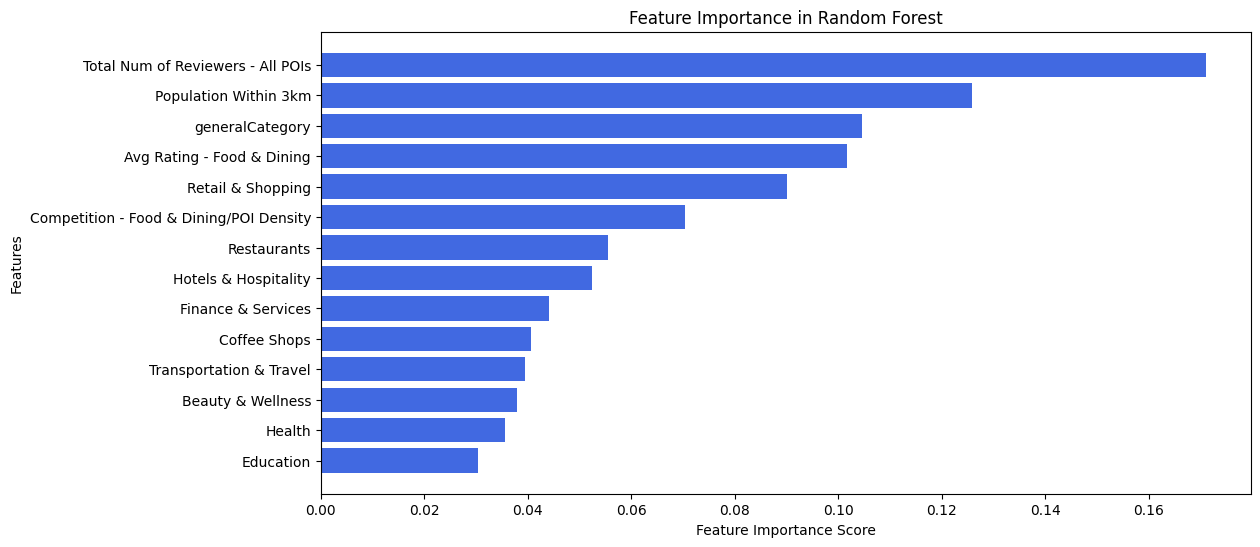


Feature Importance Scores:
                                    Feature  Importance
13        Total Num of Reviewers - All POIs    0.171161
12                    Population Within 3km    0.125920
0                           generalCategory    0.104678
10               Avg Rating - Food & Dining    0.101643
3                         Retail & Shopping    0.090006
11  Competition - Food & Dining/POI Density    0.070445
2                               Restaurants    0.055563
7                      Hotels & Hospitality    0.052448
4                        Finance & Services    0.044163
1                              Coffee Shops    0.040640
8                   Transportation & Travel    0.039434
9                         Beauty & Wellness    0.037964
6                                    Health    0.035616
5                                 Education    0.030320


In [235]:
# Compute feature importance from the best estimator
best_rf_model = grid_search.best_estimator_
feature_importance = best_rf_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()

# Display feature importance values
print("\nFeature Importance Scores:")
print(feature_importance_df)

In [253]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Container for results
results = []

# Repeat experiment 10 times
for run in range(10):
    print(f"\n==================== Run {run+1}/10 ====================")

    # -----------------------------
    # Step 3: Grid Search - Random Forest
    # -----------------------------
    rf_model = RandomForestRegressor(random_state=None)

    param_grid = {
        "n_estimators": [200],
        "max_depth": [30],
        "min_samples_split": [10],
        "min_samples_leaf": [1],
        "max_features": ["sqrt"]
    }

    grid_search = GridSearchCV(
        rf_model,
        param_grid,
        scoring='r2',
        verbose=0,
        n_jobs=-1
    )
    grid_search.fit(X_train_transformed, y_train_transformed)

    # -----------------------------
    # Step 4: Predict & Inverse Transform
    # -----------------------------
    y_pred = grid_search.best_estimator_.predict(X_test_transformed)
    y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 5: Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    # -----------------------------
    # Step 6: Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    # Remove NaN values before computing
    #mask = ~np.isnan(top_k_true) & ~np.isnan(top_k_pred)  # Keep only valid values
    #tau, _ = kendalltau(np.array(top_k_true)[mask], np.array(top_k_pred)[mask])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # -----------------------------
    # Step 7: Log Results
    # -----------------------------
    results.append({
        'run': run + 1,
        'best_params': grid_search.best_params_,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
        #f'Kendall’s Tau:': tau,
    })

# -----------------------------
# Step 8: Summary Report
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Most Frequently Selected Parameters ===")
print(results_df['best_params'].value_counts().head(3))

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run', 'best_params']).mean().round(3))
print("Last run:")
print('top_k_true',top_k_true)
print('top_k_pred',top_k_pred)



==================== Run 1/10 ====================

==================== Run 2/10 ====================

==================== Run 3/10 ====================

==================== Run 4/10 ====================

==================== Run 5/10 ====================

==================== Run 6/10 ====================

==================== Run 7/10 ====================

==================== Run 8/10 ====================

==================== Run 9/10 ====================

==================== Run 10/10 ====================

==================== Summary of 10 Runs ====================
   run                                                                                                     best_params        r2           mse         rmse         mae   ndcg@10  nSD@10
0    1  {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}  0.407323  1.499114e+06  1224.383307  570.806648  0.849635     0.3
1    2  {'max_depth': 30, 'max_features': 'sq

### XGBoost

#### Model Training and Testing

In [66]:
# -----------------------------
# Step 1: Define features and target
# -----------------------------

# Columns to drop
"""
columns_to_drop = [
    'Review_Count', 'keyword', 'Place_id', 'Indirect Competition - Food & Dining/POI Density', 
    'Population_Within_2km', 'Population_Within_1km',
    'Religious Institutions', 'Public & Government Services', 'Health',
    'Home & Construction Services', 'Education', 'Avg Rating - Restaurants', 'Avg_NumOfReviewers - Food & Dining', 'Avg_NumOfReviewers_SameCategory',
    'Avg Rating - Coffee Shops', 'Avg Num of Reviewers - Restaurants',
    'Avg Num of Reviewers - Coffee Shops',
    'Hotels & Hospitality', 'Finance & Services', 'Transportation & Travel',
    'Restaurants', 'Coffee Shops', 'Food & Dining', 'Total Num of Reviewers - Food & Dining
]
"""" 'Education','Transportation & Travel','Health','Entertainment & Recreation','Finance & Services','Beauty & Wellness','Total Num of Reviewers - All POIs','Religious Institutions','Avg Rating - Food & Dining','Hotels & Hospitality','Restaurants','Public & Government Services','Population Within 1km','Population Within 2km' """

columns_to_drop = [target_variable,'Home & Construction Services','Food & Dining','POI Density','Coffee Shops','Population Within 3km']

#training 
X_train = combined_df.drop(columns=columns_to_drop, errors='ignore')
y_train = combined_df[target_variable]

#testing
X_test = combined_df.drop(columns=columns_to_drop, errors='ignore')
y_test = combined_df[target_variable].values


In [67]:
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Initialize PowerTransformer for X
pt = PowerTransformer(method='yeo-johnson', standardize=False)  # Set standardize=False since we'll use MinMaxScaler next
scaler = MinMaxScaler()

# Fit on train and apply to both train and test
X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))
X_test_transformed = scaler.transform(pt.transform(X_test))

# Reshape y to 2D arrays (required by sklearn scalers)
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Initialize separate transformers for y
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_y = MinMaxScaler()

# Fit on training target and transform both y_train and y_test
y_train_transformed = scaler_y.fit_transform(pt_y.fit_transform(y_train_reshaped)).ravel()
y_test_transformed = scaler_y.transform(pt_y.transform(y_test_reshaped)).ravel()


In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score

# -----------------------------
# Step 4: Grid Search - XGBoost
# -----------------------------

xgb_model = XGBRegressor(objective='reg:squarederror', random_state= None)

param_grid = {
    'n_estimators': [50, 100, 200],         # Number of trees
    'max_depth': [3, 5, 6, 10],             # Maximum depth of trees
    'learning_rate': [0.01, 0.1, 0.2, 0.3], # Learning rate
    'subsample': [0.8, 1],                  # Subsample ratio
    'colsample_bytree': [0.8, 1]            # Feature fraction per tree
}


grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    cv=5
)

grid_search.fit(X_train_transformed, y_train_transformed)

y_pred = grid_search.best_estimator_.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()


# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits

--- Best Model Parameters ---
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1}

--- Regression Metrics ---
R² Score:   0.286
MSE:        1805199.284
RMSE:       1343.577
MAE:        659.087

--- Ranking Metrics ---
nDCG@10:   0.599
nSD@10:    0.700


#### Features Importance

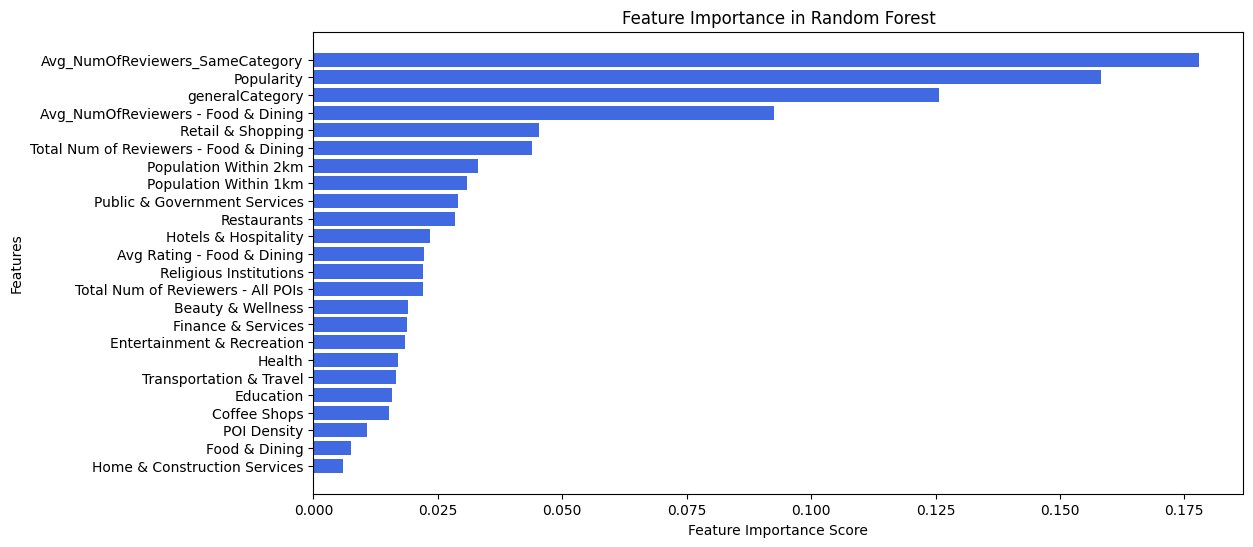


Feature Importance Scores:
                                   Feature  Importance
20         Avg_NumOfReviewers_SameCategory    0.177968
0                               Popularity    0.158303
1                          generalCategory    0.125642
19      Avg_NumOfReviewers - Food & Dining    0.092459
8                        Retail & Shopping    0.045274
22  Total Num of Reviewers - Food & Dining    0.043898
21                   Population Within 2km    0.033043
18                   Population Within 1km    0.030781
12            Public & Government Services    0.029116
5                              Restaurants    0.028498
13                    Hotels & Hospitality    0.023398
17              Avg Rating - Food & Dining    0.022235
2                   Religious Institutions    0.022071
23       Total Num of Reviewers - All POIs    0.021964
15                       Beauty & Wellness    0.018987
9                       Finance & Services    0.018764
7               Entertainment & Recre

In [ ]:
# Compute feature importance from the best estimator
best_xgb_model = grid_search.best_estimator_
feature_importance = best_xgb_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in XGboost")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()

# Display feature importance values
print("\nFeature Importance Scores:")
print(feature_importance_df)

In [69]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Container for results
results = []

# Repeat experiment 10 times
for run in range(10):
    print(f"\n==================== Run {run+1}/10 ====================")

    # -----------------------------
    # Step 3: Grid Search - XGBoost
    # -----------------------------
    xgb_model = XGBRegressor(objective='reg:squarederror', random_state=None)

    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'subsample': [0.8, 1],
        'colsample_bytree': [0.8, 1]
    }

    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        verbose=0,
        n_jobs=-1,
        cv=5
    )

    grid_search.fit(X_train_transformed, y_train_transformed)

    # -----------------------------
    # Step 4: Predict & Inverse Transform
    # -----------------------------
    y_pred = grid_search.best_estimator_.predict(X_test_transformed)
    y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 5: Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    # -----------------------------
    # Step 6: Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # -----------------------------
    # Step 7: Log Results
    # -----------------------------
    results.append({
        'run': run + 1,
        'best_params': grid_search.best_params_,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD
    })

# -----------------------------
# Step 8: Summary Report
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Most Frequently Selected Parameters ===")
print(results_df['best_params'].value_counts().head(3))

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run', 'best_params']).mean().round(3))



==================== Run 1/10 ====================

==================== Run 2/10 ====================

==================== Run 3/10 ====================

==================== Run 4/10 ====================

==================== Run 5/10 ====================

==================== Run 6/10 ====================

==================== Run 7/10 ====================

==================== Run 8/10 ====================

==================== Run 9/10 ====================

==================== Run 10/10 ====================

==================== Summary of 10 Runs ====================
   run                                        best_params        r2  \
0    1  {'colsample_bytree': 0.8, 'learning_rate': 0.1...  0.286312   
1    2  {'colsample_bytree': 0.8, 'learning_rate': 0.1...  0.286312   
2    3  {'colsample_bytree': 0.8, 'learning_rate': 0.1...  0.286312   
3    4  {'colsample_bytree': 0.8, 'learning_rate': 0.1...  0.286312   
4    5  {'colsample_bytree': 0.8, 'learning_rate': 0.1...  0.2

### SVR

In [262]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    median_absolute_error, max_error, ndcg_score
)

# -----------------------------
# Step 2: Clean & Scale
# -----------------------------

# Remove constant features
constant_features = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train = X_train.drop(columns=constant_features)
X_test = X_test.drop(columns=constant_features)
print(f"Removed constant features: {constant_features}")

# Check for NaNs or infinite values
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected.")

check_nan_inf(X_train, y_train)


# -----------------------------
# Step 3: Define SVR Model & Grid Search
# -----------------------------

model = Pipeline([
    ('svr', SVR())
])

param_grid = {
    'svr__C': [0.01, 0.1, 1, 10],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__kernel': ['rbf', 'sigmoid']
}


grid_search = GridSearchCV(model, param_grid, scoring="r2", cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_transformed, y_train_transformed)

# -----------------------------
# Step 4: Predict & Evaluate
# -----------------------------

y_pred = grid_search.best_estimator_.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


print("\n🎉 Model evaluation completed!")


Removed constant features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits

--- Best Model Parameters ---
{'svr__C': 1, 'svr__epsilon': 0.05, 'svr__gamma': 0.1, 'svr__kernel': 'rbf'}

--- Regression Metrics ---
R² Score:   0.086
MSE:        2312393.795
RMSE:       1520.656
MAE:        782.011

--- Ranking Metrics ---
nDCG@10:   0.273
nSD@10:    0.900

🎉 Model evaluation completed!


In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    ndcg_score
)

# Placeholder for logging results
results = []

for run in range(10):
    print(f"\n==================== Run {run+1}/10 ====================")

    # -----------------------------
    # Step 2: Clean & Scale
    # -----------------------------

    # Remove constant features
    constant_features = [col for col in X_train.columns if X_train[col].nunique() == 1]
    X_train = X_train.drop(columns=constant_features)
    X_test = X_test.drop(columns=constant_features)

    def check_nan_inf(X, y):
        if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
            raise ValueError("NaNs detected.")
        if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
            raise ValueError("Infinite values detected.")
        if (X.var() == 0).any():
            raise ValueError("Constant features detected.")

    check_nan_inf(X_train, y_train)


    # -----------------------------
    # Step 3: Define SVR + Grid Search
    # -----------------------------
    model = Pipeline([('svr', SVR())])

    param_grid = {
        'svr__C': [0.01, 0.1, 1, 10],
        'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
        'svr__epsilon': [0.001, 0.01, 0.05, 0.1],
        'svr__kernel': ['rbf', 'sigmoid']
    }

    grid_search = GridSearchCV(model, param_grid, scoring="r2", cv=5, n_jobs=-1, verbose=0)
    grid_search.fit(X_train_transformed, y_train_transformed)

    # -----------------------------
    # Step 4: Predict & Inverse Transform
    # -----------------------------
    y_pred = grid_search.best_estimator_.predict(X_test_transformed)
    y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 5: Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    # -----------------------------
    # Step 6: Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # -----------------------------
    # Step 7: Log Results
    # -----------------------------
    results.append({
        'run': run + 1,
        'best_params': grid_search.best_params_,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD
    })

# -----------------------------
# Step 8: Summary Report
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Most Frequently Selected Parameters ===")
print(results_df['best_params'].value_counts().head(3))

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run', 'best_params']).mean().round(3))



==================== Run 1/10 ====================

==================== Run 2/10 ====================

==================== Run 3/10 ====================

==================== Run 4/10 ====================

==================== Run 5/10 ====================

==================== Run 6/10 ====================

==================== Run 7/10 ====================

==================== Run 8/10 ====================

==================== Run 9/10 ====================

==================== Run 10/10 ====================

==================== Summary of 10 Runs ====================
   run                                                                   best_params        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  {'svr__C': 0.01, 'svr__epsilon': 0.1, 'svr__gamma': 2, 'svr__kernel': 'rbf'} -0.092668  0.036307  0.190545  0.075239  0.996486     1.0
1    2  {'svr__C': 0.01, 'svr__epsilon': 0.1, 'svr__gamma': 2, 'svr__kernel': 'rbf'} -0.092668  0.036307  0.190545  0.075239  0.996

### LSTM

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

# Repeat experiment 10 times
for run in range(10):
    print(f"\n==================== Run {run+1}/10 ====================")
    
    # -----------------------------
    # Step 3: Convert to Torch Tensors
    # -----------------------------
    X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32).unsqueeze(1).to(device)
    X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32).unsqueeze(1).to(device)
    y_train_tensor = torch.tensor(y_train_transformed, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test_transformed, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # -----------------------------
    # Step 4: Define LSTM Model
    # -----------------------------
    class LSTMRegressor(nn.Module):
        def __init__(self, input_size, hidden_size=64, num_layers=1):
            super(LSTMRegressor, self).__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            lstm_out, _ = self.lstm(x)
            out = self.fc(lstm_out[:, -1, :])
            return out.squeeze()

    model = LSTMRegressor(input_size=X_train_tensor.shape[2]).to(device)

    # -----------------------------
    # Step 5: Train the Model
    # -----------------------------
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    n_epochs = 100
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    # -----------------------------
    # Step 6: Predict
    # -----------------------------
    model.eval()
    with torch.no_grad():
        y_pred_tensor = model(X_test_tensor)

    y_pred = y_pred_tensor.cpu().numpy()
    y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 7: Evaluate
    # -----------------------------
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    # Ranking metrics
    k = 10
    true_ranks = y_test.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]
    true_relevance = np.expand_dims(y_test, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)
    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # Log results
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD
    })

# -----------------------------
# Step 8: Summary
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))



==================== Run 1/10 ====================

==================== Run 2/10 ====================

==================== Run 3/10 ====================

==================== Run 4/10 ====================

==================== Run 5/10 ====================

==================== Run 6/10 ====================

==================== Run 7/10 ====================

==================== Run 8/10 ====================

==================== Run 9/10 ====================

==================== Run 10/10 ====================


### LambdaMart